# NLP Assignment 3 - Part 2: Recurrent NMT

BiLSTM encoder, unidirectional LSTM decoder, and additive attention for French -> English translation.

First, the notebook loads the French-English dataset and tokenizers. Then it builds the recurrent NMT model from Part 2. The model has a manual BiLSTM encoder, manual LSTM decoder, and additive attention. During training, the decoder receives the previous correct English token and learns to predict the next one. After training, I save the best validation checkpoint. For inference, recurrent_inference.py provides greedy decoding and beam search. Beam search is used for BLEU evaluation and live translation. Finally, the notebook plots loss curves and attention weights, while translate_lstm.py lets me test the model interactively from the terminal.

## 0. Imports

In [2]:
import sys, os
sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.join(os.getcwd(), 'nmt_transformer'))
sys.path.insert(0, os.path.join(os.getcwd(), 'nmt_lstm'))

import torch
import matplotlib
import matplotlib.pyplot as plt
from datasets import load_from_disk

from config import *
from data import get_dataloaders
from recurrent_model import RecurrentNMT
from recurrent_inference import lstm_greedy_decode, lstm_beam_search
from train import train, save_checkpoint, load_checkpoint
from utils import compute_bleu_dataset, ids_to_tokens, plot_attention, plot_loss_curves

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BEAM_SIZE = 4

# Part 2 notebook: cleans tokenizer boundary markers so translations print as readable text.
def clean(text):
    return ' '.join(text.replace('▁', ' ').split())

print(f'Device: {DEVICE}')

Device: cuda


## 1. Load Data

In [3]:
train_loader, val_loader, test_loader, src_tokenizer, tgt_tokenizer = get_dataloaders(
    DATA_PATH, TOKENIZER_FR_PATH, TOKENIZER_EN_PATH,
    batch_size=LSTM_BATCH_SIZE, max_seq_len=MAX_SEQ_LEN,
    bos_id=BOS_ID, eos_id=EOS_ID, pad_id=PAD_ID,
)
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

ds = load_from_disk(DATA_PATH)
sample = ds['train'][0]
print(f"Sample FR: {sample['text_fr']}")
print(f"Sample EN: {sample['text_en']}")

Train batches : 272
Val   batches : 16
Test  batches : 16
Sample FR: je suis dure .
Sample EN: i m tough .


## 2. Build Recurrent Model

In [ ]:
# Creates the model:
# Using assignment hyperparameters:
# embedding size = 256
# hidden size = 512
# dropout = 0.3 (cells are less likely to overfit, but may underfit if too high)
# num layers = 1

model = RecurrentNMT(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    embed_size=LSTM_EMBED_SIZE,
    hidden_size=LSTM_HIDDEN_SIZE,
    num_layers=LSTM_NUM_LAYERS,
    dropout=LSTM_DROPOUT,
    pad_id=PAD_ID,
).to(DEVICE)

print(f'Embedding size: {LSTM_EMBED_SIZE}')
print(f'Hidden size   : {LSTM_HIDDEN_SIZE}')
print(f'Num layers    : {LSTM_NUM_LAYERS}')
print(f'Dropout       : {LSTM_DROPOUT}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Embedding size: 256
Hidden size   : 512
Num layers    : 1
Dropout       : 0.3
Total parameters: 15,509,632
RecurrentNMT(
  (encoder): BiLSTMEncoder(
    (embedding): ManualEmbedding()
    (dropout): Dropout(p=0.3, inplace=False)
    (forward_layers): ModuleList(
      (0): ManualLSTMLayer(
        (cell): ManualLSTMCell()
      )
    )
    (backward_layers): ModuleList(
      (0): ManualLSTMLayer(
        (cell): ManualLSTMCell()
      )
    )
    (init_hidden): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): AttentiveLSTMDecoder(
    (embedding): ManualEmbedding()
    (dropout): Dropout(p=0.3, inplace=False)
    (attention): AdditiveAttention(
      (decoder_proj): Linear(in_features=512, out_features=512, bias=False)
      (encoder_proj): Linear(in_features=1024, out_features=512, bias=False)
      (energy): Linear(in_features=512, out_features=1, bias=False)
    )
    (cells): ModuleList(
      (0): ManualLSTMCell()
    )
    (output): Linear(in_features=1792,

In [ ]:
# Forward pass sanity check
# This is just a check that proves the model is wired correctly.

src_ids, dec_input, targets = next(iter(train_loader))
src_ids, dec_input = src_ids.to(DEVICE), dec_input.to(DEVICE)
with torch.no_grad():
    logits, _, _, lstm_attn = model(src_ids, dec_input)

print('src_ids:', src_ids.shape)
print('dec_input:', dec_input.shape)
print('logits:', logits.shape)       # (batch, tgt_len, target_vocab)
print('attention:', lstm_attn.shape) # (batch, 1, tgt_len, src_len)
print('targets:', targets.shape)

src_ids: torch.Size([32, 13])
dec_input: torch.Size([32, 11])
logits: torch.Size([32, 11, 3200])
attention: torch.Size([32, 1, 11, 13])
targets: torch.Size([32, 11])


## 3. Train

In [ ]:
# Creates optimizer then trains the model for 10 epochs, saving the best checkpoint by validation loss.
# Validation loss was best at epoch 7, then got worse. That means overfitting started.
optimizer = torch.optim.Adam(model.parameters(), lr=LSTM_LEARNING_RATE)

train_losses, val_losses = train(
    model, train_loader, val_loader, optimizer,
    pad_id=PAD_ID, max_epochs=LSTM_MAX_EPOCHS,
    device=DEVICE, checkpoint_dir=CHECKPOINT_DIR,
    checkpoint_name='best_lstm.pt',
)

Epoch  1/10  train_loss=3.1862  val_loss=2.3291
  Checkpoint saved -> /ExtraStorage/NLP-Projects/assigment_3/checkpoints/best_lstm.pt
Epoch  2/10  train_loss=2.0763  val_loss=1.9041
  Checkpoint saved -> /ExtraStorage/NLP-Projects/assigment_3/checkpoints/best_lstm.pt
Epoch  3/10  train_loss=1.5608  val_loss=1.6351
  Checkpoint saved -> /ExtraStorage/NLP-Projects/assigment_3/checkpoints/best_lstm.pt
Epoch  4/10  train_loss=1.1430  val_loss=1.4524
  Checkpoint saved -> /ExtraStorage/NLP-Projects/assigment_3/checkpoints/best_lstm.pt
Epoch  5/10  train_loss=0.7984  val_loss=1.3628
  Checkpoint saved -> /ExtraStorage/NLP-Projects/assigment_3/checkpoints/best_lstm.pt
Epoch  6/10  train_loss=0.5248  val_loss=1.3478
  Checkpoint saved -> /ExtraStorage/NLP-Projects/assigment_3/checkpoints/best_lstm.pt
Epoch  7/10  train_loss=0.3425  val_loss=1.3416
  Checkpoint saved -> /ExtraStorage/NLP-Projects/assigment_3/checkpoints/best_lstm.pt
Epoch  8/10  train_loss=0.2333  val_loss=1.3468
Epoch  9/10  t

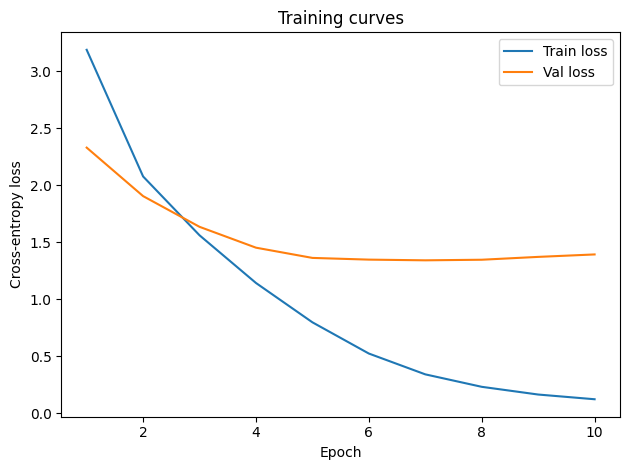

In [ ]:
# Loss Curve Cell
# This plots: training loss, validation loss 
# The plot helps you explain:  Training loss keeps decreasing, while validation loss eventually increases, so the model starts overfitting.
fig = plot_loss_curves(train_losses, val_losses)
plt.show()


## 4. Save and Load Checkpoint

In [ ]:
# Why load best checkpoint?
# Because the final epochs may overfit. The best checkpoint has the lowest validation loss.
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
save_checkpoint(
    model, optimizer, LSTM_MAX_EPOCHS, val_losses[-1],
    os.path.join(CHECKPOINT_DIR, 'final_lstm.pt'),
)

epoch, val_loss = load_checkpoint(
    model, optimizer,
    os.path.join(CHECKPOINT_DIR, 'best_lstm.pt'),
    DEVICE,
)

  Checkpoint saved -> /ExtraStorage/NLP-Projects/assigment_3/checkpoints/final_lstm.pt
Loaded checkpoint from /ExtraStorage/NLP-Projects/assigment_3/checkpoints/best_lstm.pt  (epoch 7, val_loss 1.3416)


## 5. Greedy vs. Beam Search

In [ ]:
# This compares both decoding methods.
# Difference: Greedy chooses the best token at each step, while beam search keeps multiple candidate translations and often gives better output.
test_sentences = [
    'je suis dure .',
    'il est tres intelligent .',
    'bonjour , comment ca va ?',
    'elle aime lire des livres .',
    "nous allons a l ' ecole demain .",
]

print(f"{'French':<40} {'Greedy':<30} Beam (k=4)")
print('-' * 100)
for fr in test_sentences:
    greedy_out, _ = lstm_greedy_decode(
        model, fr, src_tokenizer, tgt_tokenizer,
        MAX_SEQ_LEN, BOS_ID, EOS_ID, PAD_ID, DEVICE,
    )
    beam_out, _, _ = lstm_beam_search(
        model, fr, src_tokenizer, tgt_tokenizer,
        BEAM_SIZE, MAX_SEQ_LEN, BOS_ID, EOS_ID, PAD_ID, DEVICE,
    )
    print(f'{fr:<40} {clean(greedy_out):<30} {clean(beam_out)}')

French                                   Greedy                         Beam (k=4)
----------------------------------------------------------------------------------------------------
je suis dure .                           i m tough .                    i m tough .
il est tres intelligent .                he is very intelligent .       he is very intelligent .
bonjour , comment ca va ?                you re a good cook aren t you ? you re a good cook aren t you ?
elle aime lire des livres .              she is trying to give s .      she is trying to give s .
nous allons a l ' ecole demain .         we re going to be late again . we re going to be late again .


## 6. BLEU Score

In [ ]:
# This computes translation quality (It compares generated translations with reference translations.)
print('Computing BLEU on test set ...')
bleu_result, hypotheses, references = compute_bleu_dataset(
    model, ds['test'], src_tokenizer, tgt_tokenizer,
    beam_size=BEAM_SIZE, max_len=MAX_SEQ_LEN,
    bos_id=BOS_ID, eos_id=EOS_ID, pad_id=PAD_ID, device=DEVICE,
    decode_fn=lstm_beam_search,
)
print(f'Test BLEU = {bleu_result.score:.2f}')
print(bleu_result)

print('Sample predictions:')
for i in range(5):
    print(f'REF: {references[i]}')
    print(f'HYP: {clean(hypotheses[i])}')
    print()

Computing BLEU on test set ...


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Test BLEU = 48.09
BLEU = 48.09 73.9/52.7/40.6/33.8 (BP = 1.000 ratio = 1.008 hyp_len = 2921 ref_len = 2898)
Sample predictions:
REF: i m trustworthy .
HYP: i m getting married to tell you .

REF: i m not miserable .
HYP: i m not skinny .

REF: i m going to take my car .
HYP: i m going to my car .

REF: he s a cat lover .
HYP: he is able to cats .

REF: i m happy with that .
HYP: i m happy with it .



## 7. Attention Visualization

FR: je suis dure .
EN: i m tough .


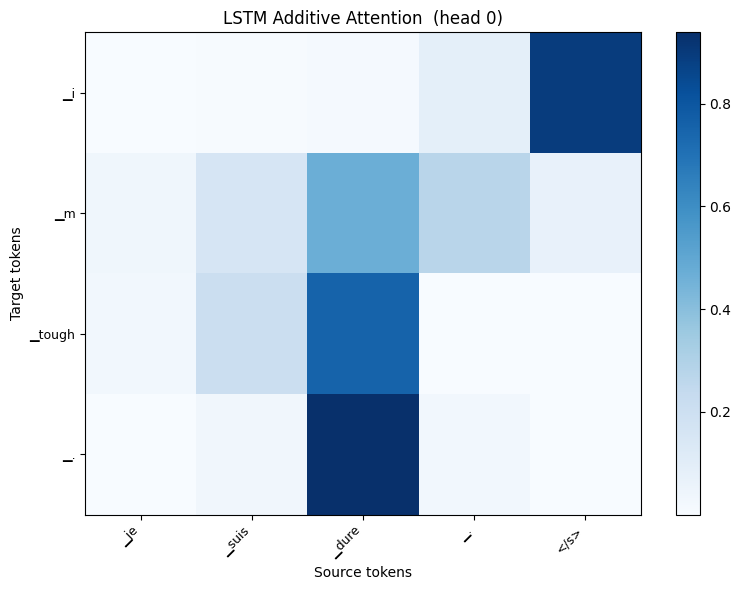

In [ ]:
# This translates one sentence and plots attention.
# x-axis = French tokens
# y-axis = English tokens
# color = attention strength
src_text = 'je suis dure .'
translation, pred_tokens, lstm_attn = lstm_beam_search(
    model, src_text, src_tokenizer, tgt_tokenizer,
    BEAM_SIZE, MAX_SEQ_LEN, BOS_ID, EOS_ID, PAD_ID, DEVICE,
)
print(f'FR: {src_text}')
print(f'EN: {clean(translation)}')

src_ids_list = src_tokenizer.encode(src_text, add_special_tokens=False)
src_ids_list = src_ids_list[: MAX_SEQ_LEN - 1] + [EOS_ID]
src_labels = ids_to_tokens(src_ids_list, src_tokenizer)
tgt_labels = ids_to_tokens(pred_tokens, tgt_tokenizer)

if lstm_attn is not None:
    attn_slice = lstm_attn[:, :, :len(tgt_labels), :len(src_labels)]
    fig = plot_attention(attn_slice, src_labels, tgt_labels,
                         title='LSTM Additive Attention')
    plt.show()

## 8. Live Translation

Use the dedicated script in the terminal:

```bash
python translate_lstm.py
python translate_lstm.py --sentence "je suis dure ."
python translate_lstm.py --show_attn
```